# **Тема:** RAG с фреймворком LlamaIndex на основе структурированных данных

**Задачи:**
* Разработка RAG-пайплайна и сравнение результатов
1. Загрузить документы (например, документацию Python-библиотеки в формате Markdown)
2. С помощью LlamaIndex создать индексы двух разных типов (на основе списков, tree-based)
2. Реализовать запрос к индексу с помощью SummaryIndex, найти и запустить другой ретривер
3. Интегрировать LLM для генерации ответов
4. Проанализировать простоту работы с библиотекой и возможности протестированных методов

**Библиотеки:** llama-index, huggingface, возможна работа с локальными моделями

**Ожидаемый результат:** Colab-ноутбук с демонстрацией процесса создания и использования различных типов индексов в LlamaIndex

## Загрузка документов

In [ ]:
!pip install llama_index -q

Document


базовая единица хранения текста

содержит метаданные, которые потом используются ретривером

In [ ]:
# вот как выглядит прямое создание документа

from llama_index.core.schema import Document

markdown_text = """
# Дни недели

## Рабочие дни

### Понедельник — бездельник

### Вторник — повторник

### Среда — тамада

### Четверг — заботы все отверг

### Пятница — пьяница

## Выходные

### Суббота — неработа

### Воскресенье — день веселья!
"""

document = Document(text=markdown_text, metadata={"file_name": "my_doc.md"})


In [ ]:
document

Document(id_='f9cbef9e-8c28-4de1-83c1-29b075c792fc', embedding=None, metadata={'file_name': 'my_doc.md'}, excluded_embed_metadata_keys=[], excluded_llm_metadata_keys=[], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='\n# Дни недели\n\n## Рабочие дни\n\n### Понедельник — бездельник\n\n### Вторник — повторник\n\n### Среда — тамада\n\n### Четверг — заботы все отверг\n\n### Пятница — пьяница\n\n## Выходные\n\n### Суббота — неработа\n\n### Воскресенье — день веселья!\n', path=None, url=None, mimetype=None), image_resource=None, audio_resource=None, video_resource=None, text_template='{metadata_str}\n\n{content}')

In [ ]:
# но нам нужно добыть документы из файлов, используя SimpleDirectoryReader:




## Создание индексов

Nodes

In [ ]:
# создаем узлы, сохраняя маркдаун-структуру

from llama_index.core.node_parser import MarkdownNodeParser # сохраняет иерархию заголовков

parser = MarkdownNodeParser()
nodes = parser.get_nodes_from_documents([document])

# проверим
for node in nodes:
    print(node.text)
    print(node.metadata)

# Дни недели
{'file_name': 'my_doc.md', 'header_path': '/'}
## Рабочие дни
{'file_name': 'my_doc.md', 'header_path': '/Дни недели/'}
### Понедельник — бездельник
{'file_name': 'my_doc.md', 'header_path': '/Дни недели/Рабочие дни/'}
### Вторник — повторник
{'file_name': 'my_doc.md', 'header_path': '/Дни недели/Рабочие дни/'}
### Среда — тамада
{'file_name': 'my_doc.md', 'header_path': '/Дни недели/Рабочие дни/'}
### Четверг — заботы все отверг
{'file_name': 'my_doc.md', 'header_path': '/Дни недели/Рабочие дни/'}
### Пятница — пьяница
{'file_name': 'my_doc.md', 'header_path': '/Дни недели/Рабочие дни/'}
## Выходные
{'file_name': 'my_doc.md', 'header_path': '/Дни недели/'}
### Суббота — неработа
{'file_name': 'my_doc.md', 'header_path': '/Дни недели/Выходные/'}
### Воскресенье — день веселья!
{'file_name': 'my_doc.md', 'header_path': '/Дни недели/Выходные/'}


In [ ]:
# но чтобы использовать файлы с фрагментами кода и таблицами нужно применить MarkdownElementNodeParser:

# попробуем тут

### Индексы на основе списков: Summary Index (formerly List Index)

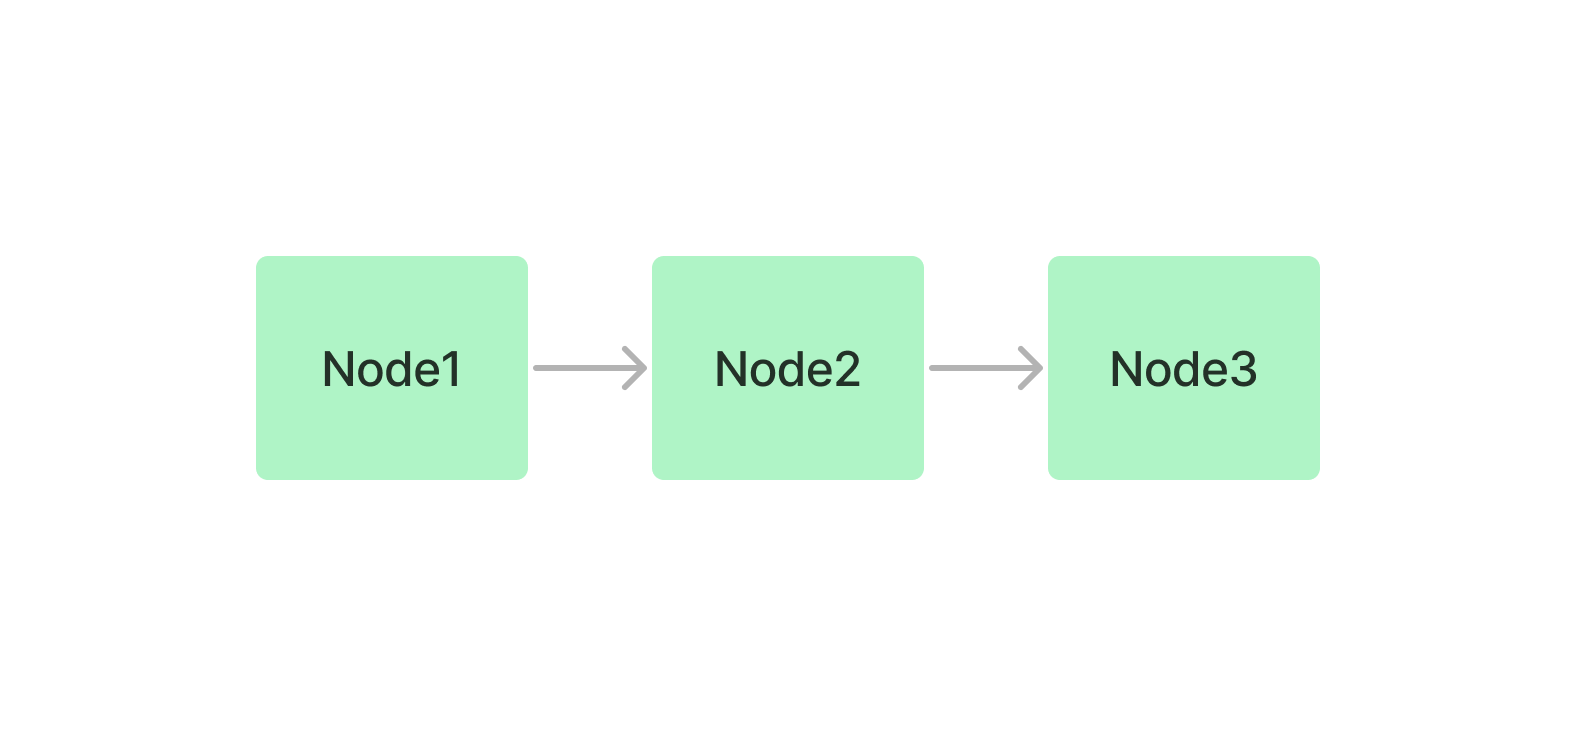


In [ ]:
# для работы с таблицами и кодом, необходимо разделение узлов на текстовые base_nodes и objects (таблицы / код)
# использовать get_nodes_and_objects

# для простых документов достаточно:
from llama_index.core.indices import SummaryIndex
index = SummaryIndex(nodes)

In [ ]:
# у SummaryIndex три режима:

# Default — проходит по всем узлам
index.as_retriever(retriever_mode="default")

# Embedding-based — выбирает близкие узлы
index.as_retriever(retriever_mode="embedding", similarity_top_k=n)

# LLM-based — выбирает узлы при помощи ллм
index.as_retriever(retriever_mode="llm")

# !! для двух последних нужна модель

In [ ]:
# выбранный вставить сюда
retriever = ""

# а здесь запрос
retrieved_nodes = retriever.retrieve("Какие дни выходные?")

In [ ]:
retrieved_nodes

### Tree-based индексы

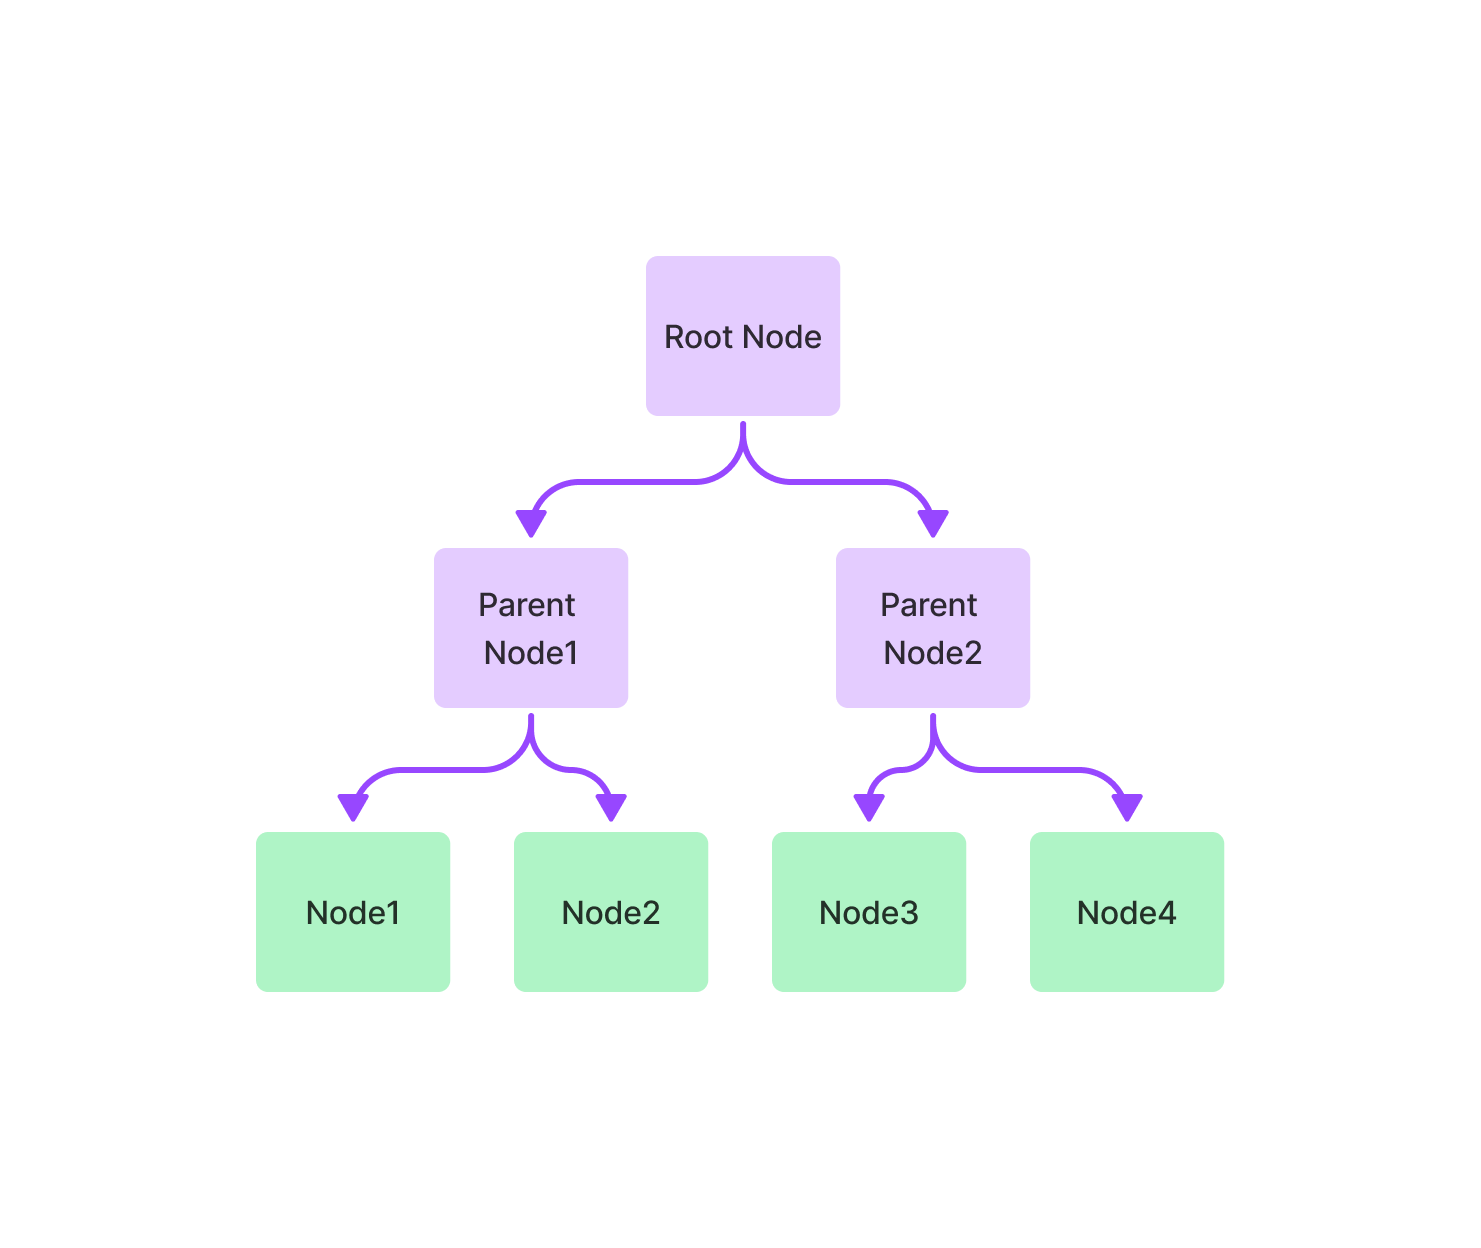

In [ ]:
# здесь пробуем применить TreeIndex

## Интеграция LLM для генерации ответов

NB: для SummaryIndex у нас уже есть retrieved_nodes

In [ ]:
from llama_index.core.response_synthesizers import get_response_synthesizer

# используем get_response_synthesizer и получаем объект Response

В случае, где retrieved_nodes нет, настраиваем LLM и используем query_engine

In [ ]:
from llama_index.llms.huggingface import HuggingFaceLLM
from llama_index.core import Settings

# настраиваем LLM
Settings.llm = HuggingFaceLLM()

# с помощью query_engine делаем retrieve и генерацию ответа


## Анализ библиотеки, сравнение методов



---



# Критерии оценки

Работа проверяется по следующим критериям (максимум 10 баллов):

### Загрузка и подготовка данных (2 балла)
- [ ] 0.5 балла: выбран источник материалов / датасет
- [ ] 0.5 балла: загружено не менее 100 записей/статей, содержащих фрагменты кода и таблицы
- [ ] 0.5 балла: успешно применен SimpleDirectoryReader
- [ ] 0.5 балла: данные приведены к в формату Document, сохранены метаданные и маркдаун-структура

### Создание узлов (2 балла)
- [ ] 0.5 балла: выбрана и вызвана LLM
- [ ] 0.5 балла: применен MarkdownElementNodeParser
- [ ] 0.5 балла: получены текстовые и объектные узлы (get_nodes_and_objects)
- [ ] 0.5 балла: проверены созданные узлы

### Summary Index (1 балл)
- [ ] 0.5 балла: выбран и применен подходящий retriever_mode
- [ ] 0.5 балла: настроены index и retriever для двух типов узлов

### Tree-based Index (1 балл)
- [ ] 0.5 балла: выбран и применен режим обхода дерева
- [ ] 0.5 балла: настроены index и retriever для двух типов узлов

### Интеграция LLM для генерации ответов (2 балла)
- [ ] 0.5 балла: выбрана LLM
- [ ] 0.5 балла: применено получение узлов (retriever.retrieve()) для обоих индексов
- [ ] 0.5 балла: использован get_response_synthesizer, получены Response (для обоих индексов)
- [ ] 0.5 балла: протестирован query_engine


### Анализ библиотеки, сравнение методов (2 балла)
- [ ] 0.5 балла: задано минимум 3 разнотипных вопроса (фактический, обобщающий, уточняющий) к обоим индексам
- [ ] 0.5 балла: для каждого вопроса показан и проанализирован ответ, сопоставлены ответы при использовании разных индексов
- [ ] 0.5 балла: проведено сравнение работы SummaryIndex и TreeIndex, сделаны выводы о возможностях методов
- [ ] 0.5 балла: сделан вывод о сильных сторонах работы с Llamaindex, применимости для разных задач

